In [12]:
import numpy as np
import pandas as pd
import geopandas as gpd
import datetime
from config import *

from matplotlib import pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
# Read in data and filter for just oru study sites
metadata = pd.read_csv(metadata_filepath)
metadata = metadata[metadata.STREAM_ID.isin(main_sites)]
metadata.head(2)

,STREAM_ID,sourceID,source,site name,latitude_wgs84,longitude_wgs84,drainagearea_sqkm,state_name,time_zone,WQ_parameters
112,STREAM-gauge-3809,3216070.0,USGS,"OHIO RIVER AT IRONTON, OH",38.532056,-82.685944,157536.14180,Ohio,Eastern,"WTemp_C,SpC_uScm,DO_mgL,pH,Turb_FNU,NO3_mgNL,C..."
140,STREAM-gauge-4431,3275500.0,USGS,"EAST FORK WHITEWATER RIVER AT RICHMOND, IN",39.806701,-84.907149,313.38879,Indiana,Eastern,"WTemp_C,SpC_uScm,DO_mgL,pH,Turb_FNU,NO3_mgNL,P..."


In [10]:
site_loads_l = []
for site in main_sites:
    load_data = pd.read_csv(load_filepath+site+'_preds_lc_flux.csv')
    
    # Reading in data and adding yearh and month columbs for grouping
    load_data = pd.read_csv(load_filepath+site+'_preds_lc_flux.csv', index_col=0)
    load_data['date'] = pd.to_datetime(load_data['date'])
    load_data['year'] = pd.DatetimeIndex(load_data['date']).year
    load_data['month'] = pd.DatetimeIndex(load_data['date']).month

    # Group by to get annual sums.
    annual_load_sum = load_data.groupby('year')['flux'].agg(flux_sum='sum', day_count='count').reset_index()

    annual_load_sum['flux_sum_kmsq_norm'] = annual_load_sum['flux_sum']/metadata[metadata['STREAM_ID'] == site]['drainagearea_sqkm'].values
    annual_load_sum.insert(0, 'STREAM_ID', site)
    site_loads_l.append(annual_load_sum)

site_annual_loads = pd.concat(site_loads_l, ignore_index=True)
site_annual_loads.head()

,STREAM_ID,year,flux_sum,day_count,flux_sum_kmsq_norm
0,STREAM-gauge-2891,2015,1.137899e+06,112,188.317575
1,STREAM-gauge-2891,2016,8.256461e+06,354,1366.410239
2,STREAM-gauge-2891,2017,6.036436e+06,363,999.005195
3,STREAM-gauge-2891,2018,6.745669e+06,366,1116.380409
4,STREAM-gauge-2891,2019,1.009174e+07,366,1670.141649


In [21]:
# Aggregating the annual values to mean values for the watershed. Only keep the ones that have full (>365 days?) records.
site_agg_loads = (site_annual_loads[site_annual_loads['day_count'] >= 365]
                  .groupby('STREAM_ID')[['flux_sum', 'flux_sum_kmsq_norm']]
                  .agg(flux_sum=('flux_sum', 'mean'), 
                       flux_sum_kmsq_norm=('flux_sum_kmsq_norm', 'mean'),
                       year=('flux_sum', 'count'))
                  .reset_index())
site_agg_loads.head()

,STREAM_ID,flux_sum,flux_sum_kmsq_norm,year
0,STREAM-gauge-2203,2.008481e+08,148.416876,7
1,STREAM-gauge-2804,1.164160e+07,75.219941,1
2,STREAM-gauge-2816,4.250247e+05,216.209259,4
3,STREAM-gauge-2891,6.848736e+06,1133.437477,6
4,STREAM-gauge-2903,1.644306e+07,4226.827899,6


In [116]:
land_use = pd.read_csv(land_use_filepath+'MRB_averaging_land_use.csv')
site_load_lu = site_agg_loads.merge(land_use, on="STREAM_ID")

# Aggregating land use categories
site_load_lu['Developed Total'] = site_load_lu['Developed Open Space'] + site_load_lu['Developed Low Intensity'] + site_load_lu['Developed Medium Intensity'] + site_load_lu['Developed High Intensity']
site_load_lu['Modified Total'] = site_load_lu['Cultivated Crops'] + site_load_lu['Developed Total']
site_load_lu['Forested Total'] = site_load_lu['Deciduous Forest'] + site_load_lu['Evergreen Forest'] + site_load_lu['Mixed Forest']

site_load_lu.head()

,STREAM_ID,flux_sum,flux_sum_kmsq_norm,year,Open Water,Perennial Ice/Snow,Developed Open Space,Developed Low Intensity,Developed Medium Intensity,Developed High Intensity,Barren Land,Deciduous Forest,Evergreen Forest,Mixed Forest,Shrub/Scrub,Grassland/Herbaceous,Pasture/Hay,Cultivated Crops,Woody Wetlands,Emergent Herbaceous Wetlands,Developed Total,Modified Total,Forested Total
0,STREAM-gauge-2203,2.008481e+08,148.416876,7,1.086690,0.004466,1.928851,1.251844,0.341356,0.065252,0.564258,2.865930,5.368286,0.183085,15.096333,36.365665,6.223003,26.624655,0.616535,1.413790,3.587303,30.211959,8.417300
1,STREAM-gauge-2804,1.164160e+07,75.219941,1,0.514210,0.000000,2.768100,1.408784,0.282966,0.055579,0.097742,2.112286,0.047260,0.053269,0.008246,39.580330,2.306290,50.069458,0.397137,0.298343,4.515429,54.584887,2.212815
2,STREAM-gauge-2816,4.250247e+05,216.209259,4,0.254382,0.000000,3.742675,2.319044,0.699816,0.147731,0.039348,1.965864,0.017918,0.001802,0.006272,25.293170,0.009404,64.966353,0.375369,0.160851,6.909266,71.875619,1.985584
3,STREAM-gauge-2891,6.848736e+06,1133.437477,6,0.336747,0.000000,3.940477,3.158269,0.754977,0.162723,0.068747,12.025259,0.010971,0.178922,0.008965,0.029438,4.290466,73.372571,1.571038,0.090429,8.016447,81.389017,12.215152
4,STREAM-gauge-2903,1.644306e+07,4226.827899,6,1.450284,0.000000,11.579881,22.717331,28.966134,11.508770,0.298273,5.658717,0.041399,0.095484,0.314559,0.326019,2.271914,9.030794,3.843672,1.896768,74.772116,83.802910,5.795600


## Plotting mean load per agricultural area

In [175]:
# Plot aesthetic
colors = ['#87bba2', '#55828b', '#3b6064', '#364958']

100000000

(-5.0, 115.0)

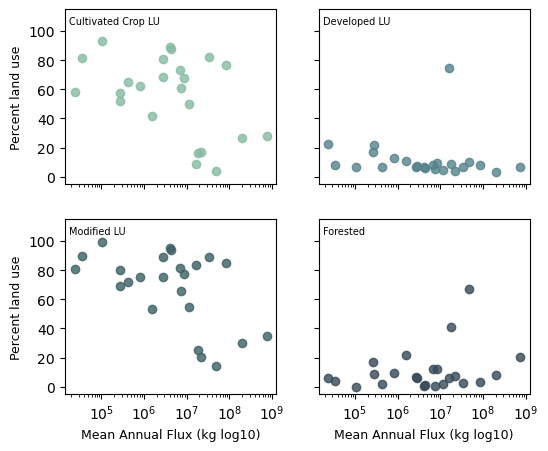

In [190]:
fig, axes = plt.subplots(2, 2, figsize=(6, 5), sharey=True, sharex=True)
ax = axes.flatten()
ax[0].scatter(site_load_lu['flux_sum'], site_load_lu['Cultivated Crops'],
               alpha=0.8,
               c=colors[0])
ax[1].scatter(site_load_lu['flux_sum'], site_load_lu['Developed Total'],
               alpha=0.8,
               c=colors[1])
ax[2].scatter(site_load_lu['flux_sum'], site_load_lu['Modified Total'],
               alpha=0.8,
               c=colors[2])
ax[3].scatter(site_load_lu['flux_sum'], site_load_lu['Forested Total'],
               alpha=0.8,
               c=colors[3])

ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[2].set_xscale('log')
ax[3].set_xscale('log')

ax[0].set_ylabel('Percent land use', fontsize=9)
ax[2].set_ylabel('Percent land use', fontsize=9)
ax[3].set_xlabel("Mean Annual Flux (kg log10)", fontsize=9)
ax[2].set_xlabel("Mean Annual Flux (kg log10)", fontsize=9)

ax[0].text(10**4.25, 105, 'Cultivated Crop LU', fontsize=7)
ax[1].text(10**4.25, 105, 'Developed LU', fontsize=7)
ax[2].text(10**4.25, 105, 'Modified LU', fontsize=7)
ax[3].text(10**4.25, 105, 'Forested', fontsize=7)

ax[0].set_ylim([-5,115])

(-5.0, 115.0)

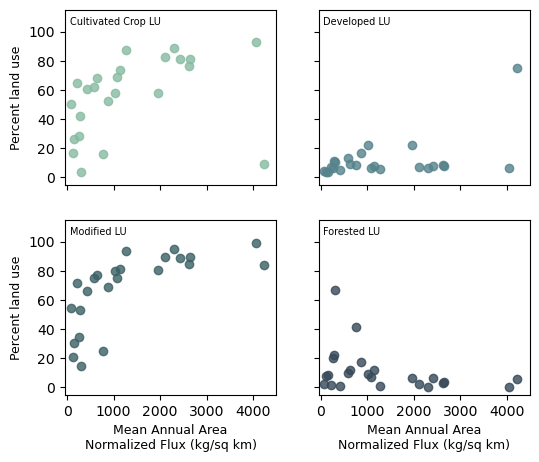

In [149]:
fig, axes = plt.subplots(2, 2, figsize=(6, 5), sharey=True, sharex=True)
ax = axes.flatten()
ax[0].scatter(site_load_lu['flux_sum_kmsq_norm'], site_load_lu['Cultivated Crops'],
               alpha=0.8,
               c=colors[0])
ax[1].scatter(site_load_lu['flux_sum_kmsq_norm'], site_load_lu['Developed Total'],
               alpha=0.8,
               c=colors[1])
ax[2].scatter(site_load_lu['flux_sum_kmsq_norm'], site_load_lu['Modified Total'],
               alpha=0.8,
               c=colors[2])
ax[3].scatter(site_load_lu['flux_sum_kmsq_norm'], site_load_lu['Forested Total'],
               alpha=0.8,
               c=colors[3])

ax[0].set_ylabel('Percent land use', fontsize=9)
ax[2].set_ylabel('Percent land use', fontsize=9)
ax[2].set_xlabel("Mean Annual Area\nNormalized Flux (kg/sq km)", fontsize=9)
ax[3].set_xlabel("Mean Annual Area\nNormalized Flux (kg/sq km)", fontsize=9)

ax[0].text(50, 105, 'Cultivated Crop LU', fontsize=7)
ax[1].text(50, 105, 'Developed LU', fontsize=7)
ax[2].text(50, 105, 'Modified LU', fontsize=7)
ax[3].text(50, 105, 'Forested LU', fontsize=7)

ax[0].set_xlim([-50,4500])
ax[0].set_ylim([-5,115])

In [151]:
basin_characteristics = pd.read_csv(OUTPUT_filepath+'MRB_STREAM_data_basin_characteristics.csv')
site_load_basinchar = site_agg_loads.merge(basin_characteristics, on="STREAM_ID")
site_load_basinchar.head()

,STREAM_ID,flux_sum,flux_sum_kmsq_norm,year,ari_ix_sav,ppd_pk_sav,rdd_mk_sav,ire_pc_sse,cly_pc_sav,slt_pc_sav,snd_pc_sav,soc_th_sav,wwtp_num,pop_served_total,waste_dis_total_m3_d,area_km2,wwtp_density_per_100km2,pct_tile_drained,pct_irrigated,septic_count,septic_density_km2,cons_conser_till_pct,cons_conven_till_pct,cons_cover_crop_pct,cons_no_till_pct,AU_density_mean,kSat_log10_cmhr,clay_pct,silt_pct,sand_pct,om_log10_pct
0,STREAM-gauge-2203,2.008481e+08,148.416876,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1789,9485598,4462125.993,1.277917e+06,0.139993,0.852623,2.332414,2.048940e+06,1.603343,6.863558,3.128232,0.791197,13.946516,18.683314,0.156942,22.594153,36.122924,38.408619,-0.503674
1,STREAM-gauge-2804,1.164160e+07,75.219941,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,397,756629,304543.929,1.501125e+05,0.264468,0.480451,8.206287,2.766891e+05,1.843211,13.631198,5.111301,1.355010,27.554032,23.938794,0.132478,23.806965,48.485348,24.581252,-0.465699
2,STREAM-gauge-2816,4.250247e+05,216.209259,4,0.620937,14.124479,275.145644,6.429391,21.904934,43.065702,35.120558,14.233835,8,18778,8785.941,1.996825e+03,0.400636,0.017967,6.431529,7.616467e+03,3.814290,16.570960,14.387245,3.724305,34.811189,21.406402,-0.120845,28.694282,47.330138,20.571490,-0.434122
3,STREAM-gauge-2891,6.848736e+06,1133.437477,6,0.920129,20.969770,343.763666,0.919432,24.741307,50.755877,24.571676,20.623302,7,67816,39746.824,6.084423e+03,0.115048,12.591607,0.029378,3.131358e+04,5.146516,26.261422,26.190156,1.735234,14.476215,11.902565,-0.067014,25.068716,52.907235,16.990072,-0.681558
4,STREAM-gauge-2903,1.644306e+07,4226.827899,6,0.955989,1380.642919,8726.544233,0.587258,21.998573,46.030810,31.902890,31.760848,39,6650230,6041638.365,3.898869e+03,1.000290,1.247528,0.000000,2.659577e+04,6.821405,3.497417,2.448311,0.343019,3.389816,2.643931,-0.033910,26.076060,43.116401,25.388671,-0.395743


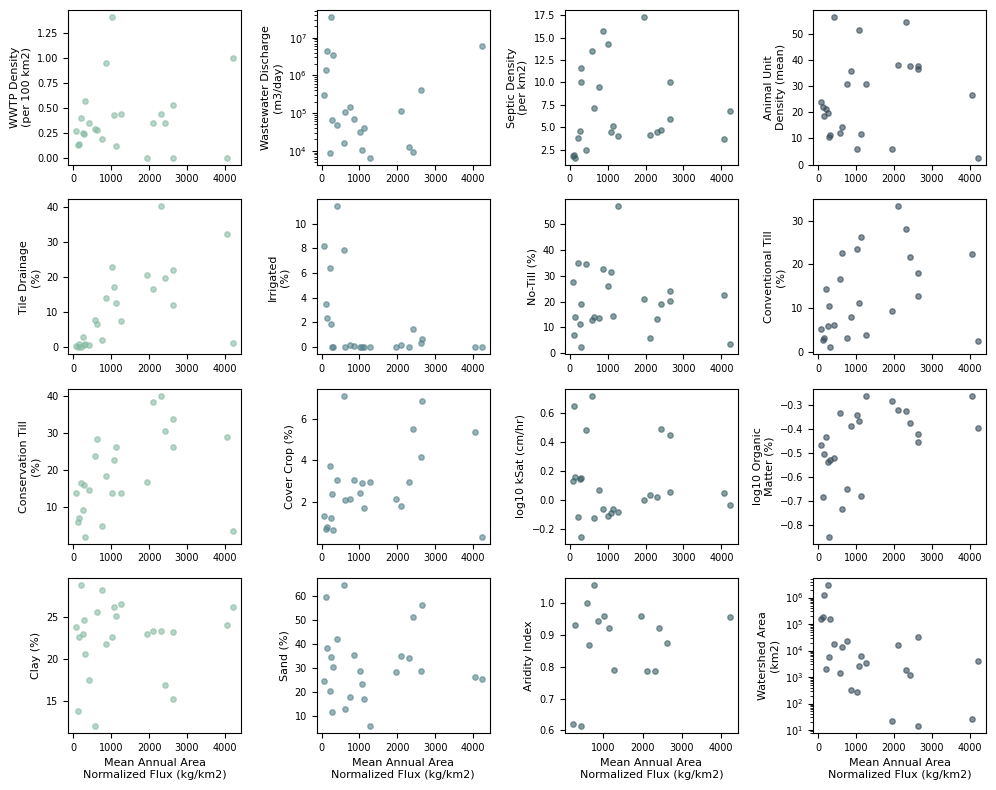

In [165]:
# Grouped by theme
basin_chars = [
    # Wastewater / point sources
    ('wwtp_density_per_100km2',     'WWTP Density\n(per 100 km2)'),
    ('waste_dis_total_m3_d',        'Wastewater Discharge\n(m3/day)'),
    ('septic_density_km2',          'Septic Density\n(per km2)'),
    # Agriculture
    ('AU_density_mean',             'Animal Unit\nDensity (mean)'),
    ('pct_tile_drained',            'Tile Drainage\n(%)'),
    ('pct_irrigated',               'Irrigated\n(%)'),
    ('cons_no_till_pct',            'No-Till (%)'),
    ('cons_conven_till_pct',        'Conventional Till\n(%)'),
    ('cons_conser_till_pct',        'Conservation Till\n(%)'),
    ('cons_cover_crop_pct',         'Cover Crop (%)'),
    # Soils
    ('kSat_log10_cmhr',             'log10 kSat (cm/hr)'),
    ('om_log10_pct',                'log10 Organic\nMatter (%)'),
    ('clay_pct',                    'Clay (%)'),
    ('sand_pct',                    'Sand (%)'),
    # Climate
    ('ari_ix_sav',                    'Aridity Index'),
    # Watershed
    ('area_km2',                    'Watershed Area\n(km2)'),
]

n = len(basin_chars)
ncols = 4
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 2), sharey=False)
ax = axes.flatten()

for i, (col, label) in enumerate(basin_chars):
    ax[i].scatter(site_load_basinchar['flux_sum_kmsq_norm'], site_load_basinchar[col],
                  alpha=0.6, c=colors[i % len(colors)], s=15)
    ax[i].set_ylabel(label, fontsize=8)
    ax[i].tick_params(labelsize=7)
    if ((col == 'area_km2') | (col == 'waste_dis_total_m3_d')):
        ax[i].set_yscale('log')
    if i >= n - ncols:
        ax[i].set_xlabel("Mean Annual Area\nNormalized Flux (kg/km2)", fontsize=8)

# Hide unused axes
for j in range(n, len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()

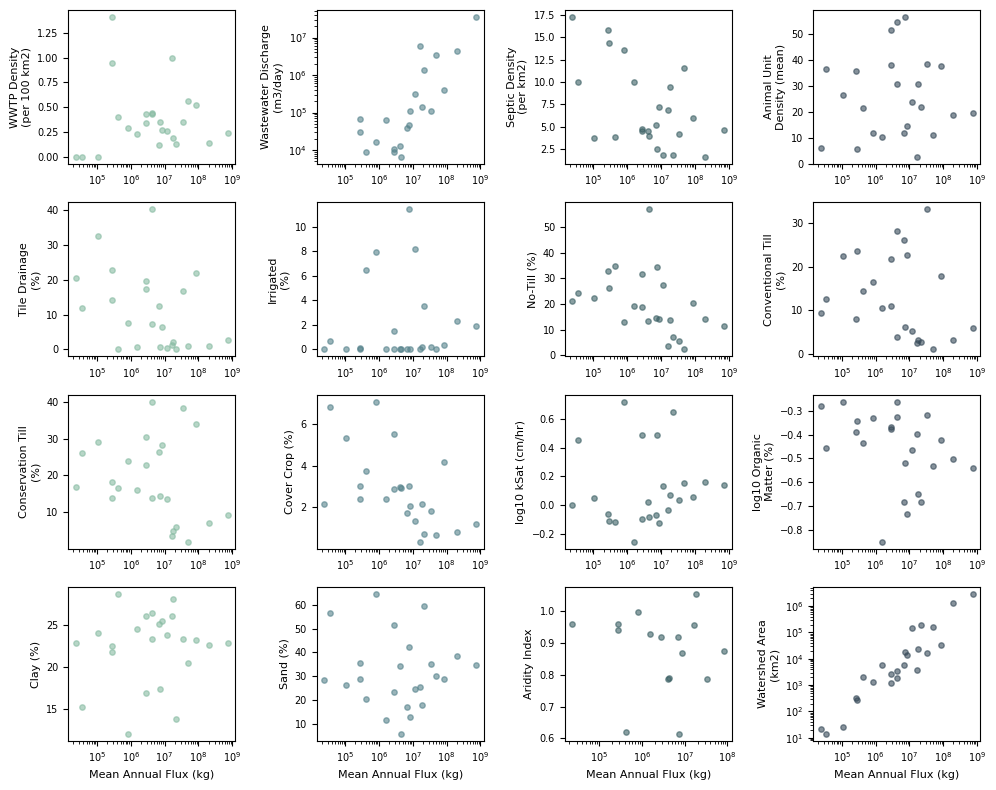

In [167]:
# Grouped by theme
basin_chars = [
    # Wastewater / point sources
    ('wwtp_density_per_100km2',     'WWTP Density\n(per 100 km2)'),
    ('waste_dis_total_m3_d',        'Wastewater Discharge\n(m3/day)'),
    ('septic_density_km2',          'Septic Density\n(per km2)'),
    # Agriculture
    ('AU_density_mean',             'Animal Unit\nDensity (mean)'),
    ('pct_tile_drained',            'Tile Drainage\n(%)'),
    ('pct_irrigated',               'Irrigated\n(%)'),
    ('cons_no_till_pct',            'No-Till (%)'),
    ('cons_conven_till_pct',        'Conventional Till\n(%)'),
    ('cons_conser_till_pct',        'Conservation Till\n(%)'),
    ('cons_cover_crop_pct',         'Cover Crop (%)'),
    # Soils
    ('kSat_log10_cmhr',             'log10 kSat (cm/hr)'),
    ('om_log10_pct',                'log10 Organic\nMatter (%)'),
    ('clay_pct',                    'Clay (%)'),
    ('sand_pct',                    'Sand (%)'),
    # Climate
    ('ari_ix_sav',                  'Aridity Index'),
    # Watershed
    ('area_km2',                    'Watershed Area\n(km2)'),
]

n = len(basin_chars)
ncols = 4
nrows = -(-n // ncols)  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(10, nrows * 2), sharey=False)
ax = axes.flatten()

for i, (col, label) in enumerate(basin_chars):
    ax[i].scatter(site_load_basinchar['flux_sum'], site_load_basinchar[col],
                  alpha=0.6, c=colors[i % len(colors)], s=15)
    ax[i].set_ylabel(label, fontsize=8)
    ax[i].tick_params(labelsize=7)
    ax[i].set_xscale('log')
    if col in ('area_km2', 'waste_dis_total_m3_d'):
        ax[i].set_yscale('log')
    if i >= n - ncols:
        ax[i].set_xlabel("Mean Annual Flux (kg)", fontsize=8)

# Hide unused axes
for j in range(n, len(ax)):
    ax[j].set_visible(False)

plt.tight_layout()
plt.show()